### 생성형 AI : 이미지 생성 개발 파이프라인

- 이 노트북은 **`이미지 생성` 개발 파이프라인 예제 실습**을 수행하는 **Google Colab용** 노트북입니다.

##### Stable Diffusion을 활용한 이미지 생성 개발 파이프라인 예제
   1.  ### Stable Diffusion을 활용한 에니메이션 캐릭터 이미지 생성 Fine-Tuning 및 성능 평가 (Cell 7개)

### Stable Diffusion을 활용한 에니메이션 캐릭터 이미지 생성 Fine-Tuning 및 성능 평가

사전학습된 Stable Diffusion 1.5 모델(`runwayml/stable-diffusion-v1-5`)을 에니메이션 캐릭터 데이터셋으로 LoRA Fine-tuning합니다.

특정 캐릭터 스타일 생성을 위해 데이터 준비부터 모델 학습, 평가까지 전체 파이프라인을 구현하여 맞춤형 이미지 생성 성능을 향상시킵니다.
* HuggingFace의 Naruto BLIP 캡션 데이터셋을 로드하고 트리거 워드를 추가하여 학습 데이터 구성
* UNet에 LoRA(Low-Rank Adaptation)를 적용하여 메모리 효율적인 파라미터 학습 설정
* Accelerate 라이브러리로 분산 학습 환경 구성 및 Mixed Precision 학습으로 속도 최적화
* 학습된 LoRA 가중치로 이미지 생성 파이프라인 구축 및 DPM 스케줄러로 생성 속도 개선
* FID Score와 CLIP Score를 통한 정량적 평가 및 생성 결과 시각화

In [ ]:
!pip install -q diffusers transformers accelerate peft torchmetrics[image] matplotlib tqdm
!pip install datasets==3.6.0
!pip install -q torch-fidelity

In [11]:
# ============================================
# Cell 1: 라이브러리 임포트
# ============================================

# 필수 라이브러리 임포트
import torch
import gc
import os
from PIL import Image
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# 한글 폰트 설정 (matplotlib)
plt.rcParams['font.family'] = 'Malgun Gothic'  
plt.rcParams['axes.unicode_minus'] = False     

# GPU 메모리 캐시 정리 함수
def clear_gpu_memory():
    torch.cuda.empty_cache()
    gc.collect()

Repo card metadata block was not found. Setting CardData to empty.


데이터셋 크기: 1221 이미지
데이터셋 컬럼: ['image', 'text']
캡션 예시: a man with dark hair and brown eyes


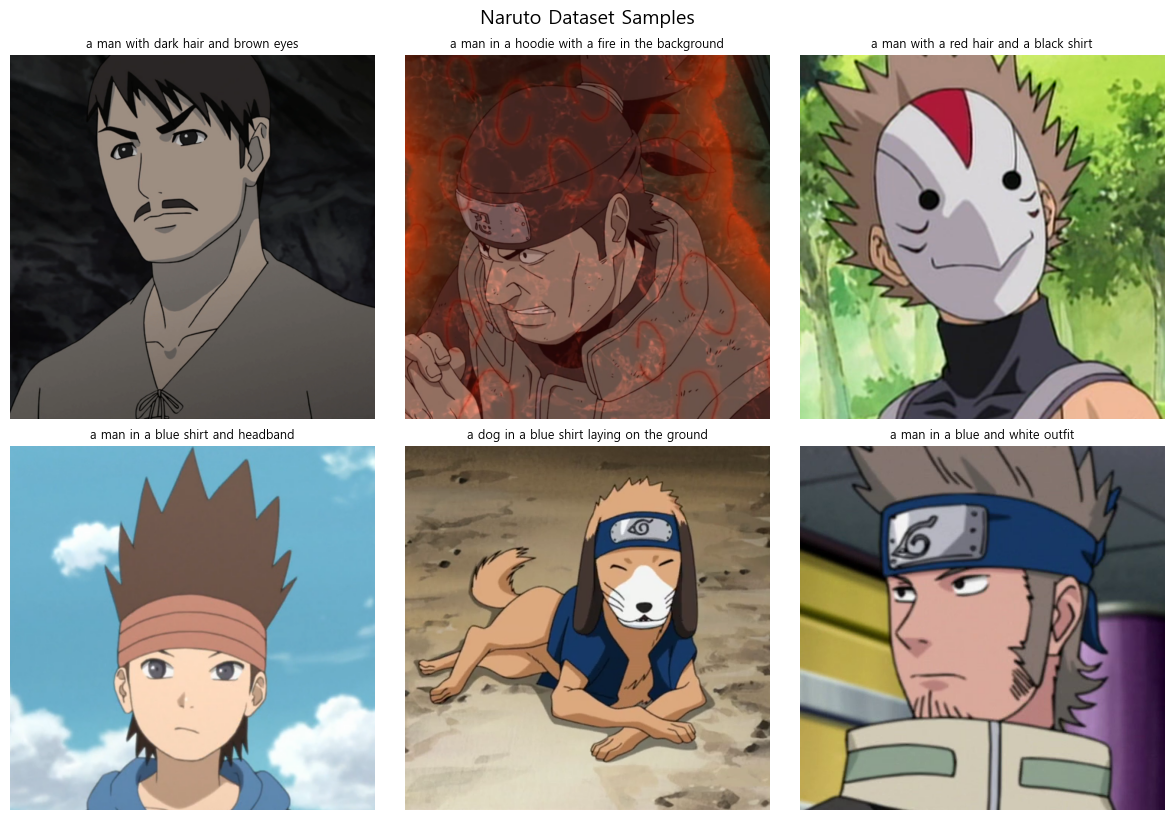

데이터셋 크기를 50개로 제한


In [12]:
# ============================================
# Cell 2: 데이터셋 로드 및 전처리
# ============================================

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# HuggingFace에서 Naruto 캐릭터 데이터셋 로드
dataset = load_dataset("lambdalabs/naruto-blip-captions", split="train")
print(f"데이터셋 크기: {len(dataset)} 이미지")
print(f"데이터셋 컬럼: {dataset.column_names}")

# 데이터 샘플 확인
sample = dataset[0]
print(f"캡션 예시: {sample['text']}")

def visualize_dataset_samples(dataset, num_samples=6):
    """
    데이터셋 샘플 이미지와 캡션을 시각화
    
    Args:
        dataset: HuggingFace 데이터셋
        num_samples (int): 표시할 샘플 수
    """
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    for i in range(min(num_samples, len(dataset))):
        img = dataset[i]['image']
        caption = dataset[i]['text']
        
        axes[i].imshow(img)
        axes[i].axis('off')
        # 캡션이 길면 50자로 자르고 ... 추가
        axes[i].set_title(caption[:50] + "..." if len(caption) > 50 else caption, 
                         fontsize=9, wrap=True)
    
    plt.tight_layout()
    plt.suptitle("Naruto Dataset Samples", fontsize=14, y=1.02)
    plt.show()


class NarutoLoRADataset(Dataset):
    """
    LoRA 학습을 위한 커스텀 데이터셋 클래스
    """
    def __init__(self, hf_dataset, trigger_word="naruto character", size=512):
        """
        Args:
            hf_dataset: HuggingFace 데이터셋
            trigger_word (str): 스타일 학습을 위한 트리거 워드
            size (int): 이미지 크기
        """
        self.dataset = hf_dataset
        self.trigger_word = trigger_word
        self.size = size
        
        # 이미지 전처리 파이프라인
        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])  # [-1, 1]로 정규화
        ])
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        print(item)
        
        # RGB 이미지로 변환
        image = item['image'].convert('RGB')
        
        # 캡션에 트리거 워드 추가
        caption = f"{self.trigger_word}, {item['text']}"
        
        return {
            'pixel_values': self.transform(image),
            'input_ids': caption
        }

# 데이터셋 샘플 시각화
visualize_dataset_samples(dataset)

# 빠른 학습을 위해 데이터셋 크기 제한
num_samples = 50
if num_samples and num_samples < len(dataset):
    dataset = dataset.select(range(num_samples))
    print(f"데이터셋 크기를 {num_samples}개로 제한")

In [13]:
# ============================================
# Cell 3: 모델 로드 및 LoRA 설정
# ============================================

from diffusers import StableDiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model, TaskType

# Stable Diffusion 1.5 모델 ID
model_id = "runwayml/stable-diffusion-v1-5"

# 모델 컴포넌트 개별 로드
tokenizer = CLIPTokenizer.from_pretrained(model_id, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder", torch_dtype=torch.float16, device_map="auto")
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16)

# 메모리 최적화를 위한 gradient checkpointing 활성화
unet.enable_gradient_checkpointing()
text_encoder.gradient_checkpointing_enable()

# LoRA 설정
unet_lora_config = LoraConfig(
    r=32,  # LoRA rank (낮을수록 파라미터 수 감소)
    lora_alpha=32,  # LoRA scaling factor
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],  # Attention 레이어만 학습
    lora_dropout=0.1,  # 드롭아웃 비율
)

# UNet에 LoRA 어댑터 추가
unet = get_peft_model(unet, unet_lora_config)
unet.print_trainable_parameters()  # 학습 가능한 파라미터 정보 출력

trainable params: 6,377,472 || all params: 865,898,436 || trainable%: 0.7365


In [14]:
# ============================================
# Cell 4: 학습 설정 및 데이터로더 준비
# ============================================

from accelerate import Accelerator
from diffusers import AutoencoderKL, DDPMScheduler
import torch.nn.functional as F

# 학습 하이퍼파라미터
learning_rate = 1e-4
train_batch_size = 1
num_train_epochs = 1
gradient_accumulation_steps = 2  # 성능을 위해 2로 조정 (효과적 배치 크기 = 1 * 4 = 4)

# Accelerator로 분산 학습 환경 설정
accelerator = Accelerator(
    gradient_accumulation_steps=gradient_accumulation_steps,
    mixed_precision="fp16"  # 16비트 부동소수점으로 메모리 절약
)

# VAE(Variational Autoencoder)와 노이즈 스케줄러 로드
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
noise_scheduler = DDPMScheduler.from_pretrained(model_id, subfolder="scheduler")

# AdamW 옵티마이저 설정
optimizer = torch.optim.AdamW(
    unet.parameters(),
    lr=learning_rate,
    betas=(0.9, 0.999),  # Adam 베타 파라미터
    weight_decay=0.01,  # L2 정규화
    eps=1e-08,
)

# 데이터로더 생성
dataset = NarutoLoRADataset(dataset)
train_dataloader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True)

# Accelerator로 모델과 데이터로더 준비
unet, optimizer, train_dataloader = accelerator.prepare(
    unet, optimizer, train_dataloader
)
vae.to(accelerator.device)
text_encoder.to(accelerator.device)

def train_lora(num_epochs=1, save_every_n_epochs=1):
    """
    LoRA 학습 함수
    
    Args:
        num_epochs (int): 학습 에포크 수
        save_every_n_epochs (int): 체크포인트 저장 주기
    """
    global_step = 0
    
    for epoch in range(num_epochs):
        unet.train()
        epoch_loss = 0
        
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch}")
        for step, batch in enumerate(progress_bar):
            with accelerator.accumulate(unet):
                # 이미지를 잠재 공간으로 인코딩
                latents = vae.encode(batch["pixel_values"]).latent_dist.sample()
                latents = latents * vae.config.scaling_factor
                
                # 랜덤 노이즈 생성
                noise = torch.randn_like(latents)
                # 랜덤 타임스텝 선택
                timesteps = torch.randint(
                    0, noise_scheduler.config.num_train_timesteps, 
                    (latents.shape[0],), device=latents.device
                ).long()
                
                # 노이즈 추가 (forward diffusion)
                noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
                
                # 텍스트 인코딩
                input_ids = tokenizer(
                    batch["input_ids"], 
                    padding="max_length",
                    max_length=tokenizer.model_max_length,
                    truncation=True,
                    return_tensors="pt"
                ).input_ids.to(accelerator.device)
                
                encoder_hidden_states = text_encoder(input_ids)[0]
                
                # UNet으로 노이즈 예측
                model_pred = unet(noisy_latents, timesteps, encoder_hidden_states).sample
                
                # MSE 손실 계산
                loss = F.mse_loss(model_pred.float(), noise.float(), reduction="mean")
                
                # 역전파
                accelerator.backward(loss)
                optimizer.step()
                optimizer.zero_grad()
                
                epoch_loss += loss.item()
            
            # 진행 상황 업데이트
            progress_bar.set_postfix(loss=loss.item())
            global_step += 1
        
        # 에포크 종료 시 평균 손실 출력
        avg_loss = epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch} - Average Loss: {avg_loss:.4f}")
        
        # 주기적으로 체크포인트 저장
        if (epoch + 1) % save_every_n_epochs == 0:
            save_path = f"./lora_checkpoint_epoch_{epoch+1}"
            unet.save_pretrained(save_path)
            print(f"PEFT 체크포인트 저장: {save_path}")

# 학습 실행 (10 에포크, 5 에포크마다 저장)
train_lora(num_epochs=1, save_every_n_epochs=1)

Epoch 0:   0%|          | 0/50 [00:00<?, ?it/s]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1080x1080 at 0x22FF43235B0>, 'text': 'a person with long white hair and blue eyes'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1260x1260 at 0x22FF43204F0>, 'text': 'a man with a white hat and a red cross on his head'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1076x1076 at 0x23028FD51E0>, 'text': 'a man with a mask on his face'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1080x1080 at 0x23001719ED0>, 'text': 'a man with a white hair and a blue shirt'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1080x1080 at 0x22FF4252E60>, 'text': 'a man with dark hair and brown eyes'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1620x1620 at 0x23028F7BC70>, 'text': 'a girl with long hair and a pink shirt'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=700x700 at 0x23029351090>, 'text': 'a man with a red hair and a black shirt'}


In [15]:
# ============================================
# Cell 5: 추론 파이프라인 구성
# ============================================

from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from peft import PeftModel

def save_lora_weights_diffusers(unet, save_path):
    """
    LoRA 가중치를 diffusers 형식으로 저장
    
    Args:
        unet: LoRA가 적용된 UNet 모델
        save_path (str): 저장 경로
    """
    import os
    os.makedirs(save_path, exist_ok=True)
    
    # LoRA 레이어만 추출
    lora_state_dict = {}
    for name, param in unet.named_parameters():
        if "lora" in name:
            lora_state_dict[name] = param.cpu().data
    
    # 가중치 저장
    import torch
    torch.save(lora_state_dict, os.path.join(save_path, "pytorch_lora_weights.bin"))
    print(f"Diffusers 형식 LoRA 가중치 저장: {save_path}")

def load_lora_pipeline(checkpoint_path):
    """
    학습된 LoRA 가중치로 생성 파이프라인 구성
    
    Args:
        checkpoint_path (str): LoRA 체크포인트 경로
    
    Returns:
        StableDiffusionPipeline: 설정된 파이프라인
    """
    # 기본 Stable Diffusion 파이프라인 로드
    pipe = StableDiffusionPipeline.from_pretrained(
        "runwayml/stable-diffusion-v1-5",
        torch_dtype=torch.float16,  # 메모리 절약
        safety_checker=None,  # 안전 체커 비활성화
        requires_safety_checker=False
    )
    
    # 학습된 LoRA 가중치 로드
    pipe.unet = PeftModel.from_pretrained(pipe.unet, checkpoint_path)
    
    # DPM 스케줄러로 변경 (더 빠른 생성)
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    
    # GPU로 이동
    pipe = pipe.to("cuda")
    
    # 메모리 최적화
    pipe.enable_attention_slicing()
    
    return pipe

def generate_images(pipe, prompts, num_images_per_prompt=4):
    """
    이미지 생성 함수
    
    Args:
        pipe: StableDiffusion 파이프라인
        prompts (list): 생성할 프롬프트 리스트
        num_images_per_prompt (int): 프롬프트당 생성할 이미지 수
    
    Returns:
        list: 생성된 이미지 리스트
    """
    all_images = []
    # CPU 오프로딩 활성화
    pipe.enable_model_cpu_offload()
    pipe.enable_attention_slicing()
    
    for prompt in prompts:
        clear_gpu_memory()  # 각 생성 전 메모리 정리
        images = pipe(
            prompt=prompt,
            negative_prompt="low quality, blurry, distorted, deformed",
            num_images_per_prompt=num_images_per_prompt,
            num_inference_steps=25,  # 디노이징 스텝 수
            guidance_scale=7.5,  # CFG(Classifier-Free Guidance) 스케일
            generator=torch.Generator("cuda").manual_seed(42)  # 재현성을 위한 시드
        ).images
        
        all_images.extend(images)
    
    return all_images

def enhance_image(image):
    """
    생성된 이미지 후처리 (향상)
    
    Args:
        image: PIL Image
    
    Returns:
        PIL Image: 향상된 이미지
    """
    from PIL import ImageEnhance
    
    # 대비 향상
    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(1.1)
    
    # 선명도 향상
    enhancer = ImageEnhance.Sharpness(image)
    image = enhancer.enhance(1.1)
    
    return image

# Naruto 스타일 생성을 위한 테스트 프롬프트
test_prompts = [
    "naruto character, ninja portrait, detailed face, anime style",
    "naruto character, action pose, orange outfit, leaf village background",
    "naruto character, close-up face, determined expression, anime art"
]

# 파이프라인 로드 및 이미지 생성
pipe = load_lora_pipeline("./lora_checkpoint_epoch_1")
generated_images = generate_images(pipe, test_prompts)
enhanced_images = [enhance_image(img) for img in generated_images]

# 생성된 이미지 저장
print("\n5. 결과 저장 중...")
os.makedirs("./generated_images", exist_ok=True)
for i, (img, prompt) in enumerate(zip(enhanced_images, test_prompts * 4)):
    img.save(f"./generated_images/naruto_{i:03d}.png")

print("\n완료! 결과는 ./generated_images 폴더에 저장되었습니다.")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]


5. 결과 저장 중...

완료! 결과는 ./generated_images 폴더에 저장되었습니다.


In [16]:
# ============================================
# Cell 6: 모델 평가 메트릭
# ============================================

import torchvision.transforms as T
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.functional.multimodal import clip_score

class ModelEvaluator:
    """
    생성 모델 평가를 위한 클래스
    FID와 CLIP Score 계산
    """
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # FID 메트릭 초기화
        self.fid = FrechetInceptionDistance(feature=2048, normalize=False).to(self.device)
        # FID용 이미지 전처리
        self.fid_transform = T.Compose([
            T.Resize((299, 299)),  # Inception 모델 입력 크기
            T.ToTensor(),
        ])
    
    def save_original_images(self, dataset, save_dir, num_images=50):
        """
        원본 데이터셋 이미지를 로컬에 저장 (FID 계산용)
        
        Args:
            dataset: HuggingFace 데이터셋
            save_dir (str): 저장 디렉토리
            num_images (int): 저장할 이미지 수
        
        Returns:
            str: 저장 디렉토리 경로
        """
        import os
        os.makedirs(save_dir, exist_ok=True)
        
        for i in range(min(num_images, len(dataset))):
            data = dataset[i]
            if 'image' in data:
                img = data['image'].convert('RGB')
                img = img.resize((512, 512), Image.Resampling.LANCZOS)
                img.save(os.path.join(save_dir, f"original_{i:04d}.png"))
            elif 'pixel_values' in data:
                img = transforms.ToPILImage()(data['pixel_values']).convert('RGB')
                img = img.resize((512, 512), Image.Resampling.LANCZOS)
                img.save(os.path.join(save_dir, f"original_{i:04d}.png"))
            else:
                print(f"Index {i}에 이미지 관련 키가 없음: {data.keys()}")
                continue
        
        print(f"원본 이미지 {num_images}개를 {save_dir}에 저장했습니다.")
        return save_dir
    
    def calculate_fid(self, real_images_path, generated_images_path):
        """
        FID(Fréchet Inception Distance) 점수 계산
        낮을수록 실제 이미지와 유사
        
        Args:
            real_images_path (str): 실제 이미지 디렉토리
            generated_images_path (str): 생성된 이미지 디렉토리
        
        Returns:
            float: FID 점수
        """
        import os
        
        # 디렉토리 존재 확인
        if not os.path.exists(real_images_path):
            print(f"경고: 실제 이미지 경로가 없습니다: {real_images_path}")
            return None
        if not os.path.exists(generated_images_path):
            print(f"경고: 생성된 이미지 경로가 없습니다: {generated_images_path}")
            return None
        
        # FID 메트릭 초기화
        self.fid.reset()
        
        # 실제 이미지 처리
        real_count = 0
        for img_file in os.listdir(real_images_path):
            if img_file.endswith(('.jpg', '.png')):
                img = Image.open(os.path.join(real_images_path, img_file)).convert('RGB')
                img_tensor = self.fid_transform(img)
                # uint8 형식으로 변환 (0-255 범위)
                img_tensor = (img_tensor * 255).byte()
                img_tensor = img_tensor.unsqueeze(0).to(self.device)
                self.fid.update(img_tensor, real=True)
                real_count += 1
        
        # 생성된 이미지 처리
        gen_count = 0
        for img_file in os.listdir(generated_images_path):
            if img_file.endswith(('.jpg', '.png')):
                img = Image.open(os.path.join(generated_images_path, img_file)).convert('RGB')
                img_tensor = self.fid_transform(img)
                # uint8 형식으로 변환 (0-255 범위)
                img_tensor = (img_tensor * 255).byte()
                img_tensor = img_tensor.unsqueeze(0).to(self.device)
                self.fid.update(img_tensor, real=False)
                gen_count += 1
        
        print(f"FID 계산: 실제 이미지 {real_count}개, 생성 이미지 {gen_count}개")
        
        if real_count == 0 or gen_count == 0:
            print("경고: 이미지가 없어 FID를 계산할 수 없습니다.")
            return None
        
        try:
            fid_score = float(self.fid.compute())
            return fid_score
        except Exception as e:
            print(f"FID 계산 중 에러 발생: {e}")
            return None
    
    def calculate_clip_score(self, images, prompts):
        """
        CLIP Score 계산
        높을수록 텍스트-이미지 일치도가 높음
        
        Args:
            images (list): PIL 이미지 리스트
            prompts (list): 프롬프트 리스트
        
        Returns:
            float: 평균 CLIP Score
        """
        try:
            scores = []
            # PIL 이미지를 텐서로 변환
            image_tensors = []
            for img in images:
                img_array = np.array(img)
                img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)
                image_tensors.append(img_tensor)
            
            images_tensor = torch.stack(image_tensors)
            
            # 각 프롬프트에 대한 점수 계산
            for i, prompt in enumerate(prompts):
                if i < len(images_tensor):
                    score = clip_score(
                        images_tensor[i:i+1], 
                        [prompt],
                        model_name_or_path="openai/clip-vit-base-patch32"
                    )
                    scores.append(float(score))
            
            return np.mean(scores) if scores else 0.0
        except Exception as e:
            print(f"CLIP Score 계산 중 에러 발생: {e}")
            return 0.0

def evaluate_generated_images(dataset, generated_images, prompts):
    """
    생성된 이미지 종합 평가
    
    Args:
        dataset: 원본 데이터셋
        generated_images (list): 생성된 이미지 리스트
        prompts (list): 사용된 프롬프트 리스트
    
    Returns:
        tuple: (FID Score, CLIP Score)
    """
    evaluator = ModelEvaluator()
    
    # 1. 원본 이미지 저장
    original_dir = "./original_images"
    evaluator.save_original_images(dataset, original_dir, num_images=50)
    
    # 2. 생성된 이미지 저장
    generated_dir = "./generated_images"
    os.makedirs(generated_dir, exist_ok=True)
    for i, img in enumerate(generated_images):
        img.save(os.path.join(generated_dir, f"generated_{i:04d}.png"))
    print(f"생성된 이미지 {len(generated_images)}개를 {generated_dir}에 저장했습니다.")
    
    # 3. FID 계산
    fid_score = evaluator.calculate_fid(original_dir, generated_dir)
    
    # 4. CLIP Score 계산
    clip_score_val = evaluator.calculate_clip_score(
        generated_images[:len(prompts)], 
        prompts
    )
    
    print(f"\n평가 결과:")
    if fid_score is not None:
        print(f"FID Score: {fid_score:.2f}")
    else:
        print("FID Score: 계산 실패")
    print(f"CLIP Score: {clip_score_val:.2f}")
    
    return fid_score, clip_score_val

# 평가 실행
fid_score, clip_score_val = evaluate_generated_images(dataset, enhanced_images, test_prompts)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1080x1080 at 0x23040642800>, 'text': 'a man with dark hair and brown eyes'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=937x937 at 0x23040642680>, 'text': 'a man in a hoodie with a fire in the background'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=700x700 at 0x230406427D0>, 'text': 'a man with a red hair and a black shirt'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1848x1848 at 0x23040642CB0>, 'text': 'a man in a blue shirt and headband'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=477x477 at 0x23040643010>, 'text': 'a dog in a blue shirt laying on the ground'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=488x488 at 0x23040643040>, 'text': 'a man in a blue and white outfit'}
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1080x1080 at 0x230406439D0>, 'text': 'a man with a white hair and a blue shirt'}
{'image': <

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.



평가 결과:
FID Score: 241.50
CLIP Score: 29.50


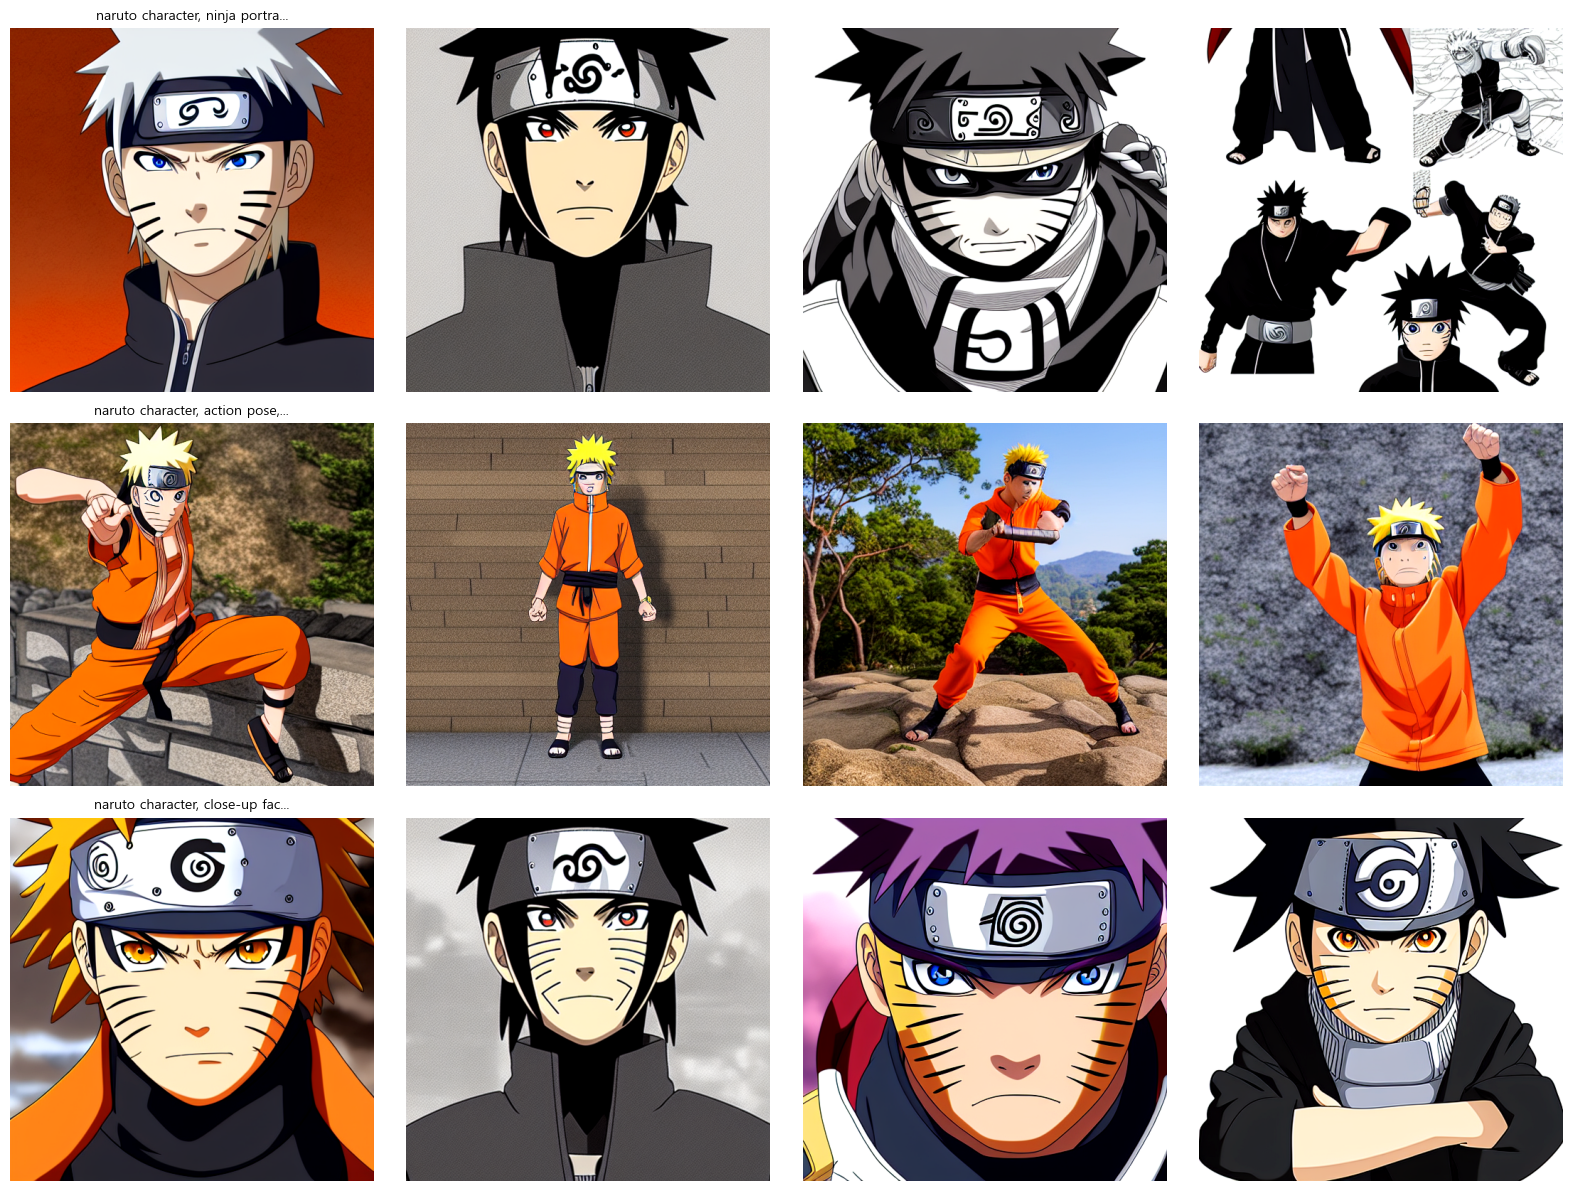

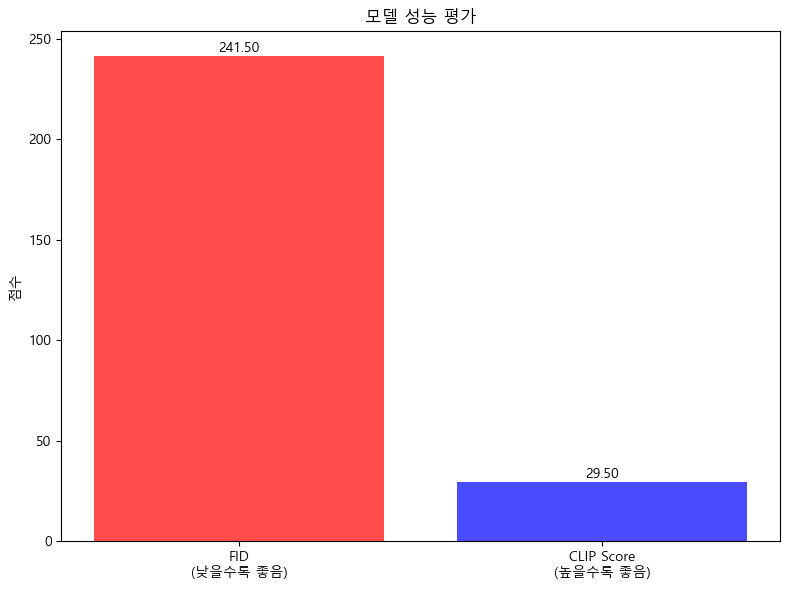

In [17]:
# ============================================
# Cell 7: 결과 시각화
# ============================================

def visualize_results(images, prompts, scores=None):
    """
    생성 결과를 그리드로 시각화
    
    Args:
        images (list): 생성된 이미지 리스트
        prompts (list): 사용된 프롬프트 리스트
        scores (dict, optional): 평가 점수
    """
    fig, axes = plt.subplots(len(prompts), 4, figsize=(16, 4*len(prompts)))
    
    for i, prompt in enumerate(prompts):
        for j in range(4):
            idx = i * 4 + j
            if idx < len(images):
                axes[i, j].imshow(images[idx])
                axes[i, j].axis('off')
                if j == 0:
                    # 첫 번째 열에만 프롬프트 표시
                    axes[i, j].set_title(prompt[:30] + "...", fontsize=10)
    
    plt.tight_layout()
    plt.savefig("generation_results.png", dpi=150)
    plt.show()

def plot_evaluation_scores(fid_score, clip_score_val):
    """
    평가 점수를 막대 그래프로 시각화
    
    Args:
        fid_score (float): FID 점수
        clip_score_val (float): CLIP 점수
    """
    metrics = ['FID\n(낮을수록 좋음)', 'CLIP Score\n(높을수록 좋음)']
    scores = [fid_score, clip_score_val]
    colors = ['red', 'blue']
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(metrics, scores, color=colors, alpha=0.7)
    
    # 막대 위에 점수 표시
    for bar, score in zip(bars, scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{score:.2f}', ha='center', va='bottom')
    
    plt.title('모델 성능 평가')
    plt.ylabel('점수')
    plt.tight_layout()
    plt.savefig("evaluation_scores.png", dpi=150)
    plt.show()

# 시각화 실행
visualize_results(enhanced_images, test_prompts)
plot_evaluation_scores(fid_score, clip_score_val)